In [2]:
!pip install -q scikit-image scikit-learn

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, data
from skimage.feature import graycomatrix, graycoprops   # skimage < 0.19 dùng greycomatrix/greycoprops
import requests
from io import BytesIO
from PIL import Image

np.set_printoptions(precision=4, suppress=True)
print("Import thành công! Sẵn sàng bắt đầu bài Lab.")

Import thành công! Sẵn sàng bắt đầu bài Lab.


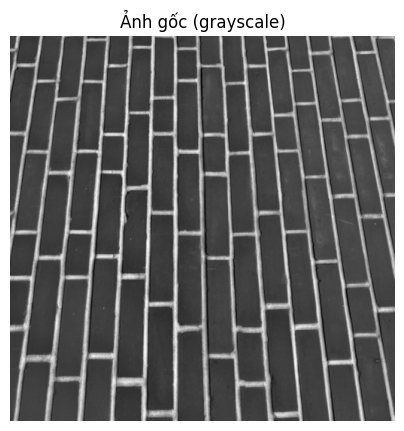

In [6]:
# BƯỚC 1.1 — Hàm tải ảnh an toàn (có phương án dự phòng nếu mất mạng)
def load_demo_image():
    try:
        # Ảnh mẫu: kết cấu vải/gạch từ skimage (built-in, luôn có sẵn offline)
        img = data.brick()
        return img
    except Exception as e:
        print("Dùng ảnh synthetic thay thế:", e)
        rng = np.random.default_rng(0)
        img = (rng.normal(128, 40, (256, 256))).clip(0, 255).astype(np.uint8)
        return img

image = load_demo_image()

plt.figure(figsize=(5,5))
plt.imshow(image, cmap='gray')
plt.title("Ảnh gốc (grayscale)")
plt.axis('off')
plt.show()

In [7]:
print("Kích thước ảnh:", image.shape)
print("Mức xám nhỏ nhất / lớn nhất:", image.min(), "/", image.max())

Kích thước ảnh: (512, 512)
Mức xám nhỏ nhất / lớn nhất: 63 / 207


In [9]:
# BƯỚC 2.1 — Lượng tử hóa ảnh về Ng mức xám
def quantize_image(img, n_levels=8):
  """Chia đều [0,255] thành n_levels mức, trả về ảnh mã hoá 0..n_levels-1 (kiểu
  uint8)."""
  bins = np.linspace(0, 256, n_levels + 1)
  quantized = np.digitize(img, bins) - 1
  quantized = np.clip(quantized, 0, n_levels - 1).astype(np.uint8)
  return quantized

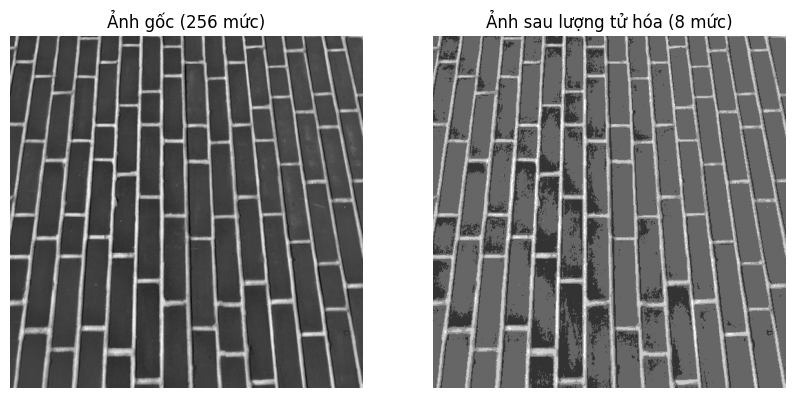

In [13]:
N_LEVELS = 8   # <-- Sinh viên có thể thử đổi thành 16, 32 để xem GLCM thay đổi ra sao
img_q = quantize_image(image, N_LEVELS)
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(image, cmap='gray'); ax[0].set_title("Ảnh gốc (256 mức)");
ax[0].axis('off')
ax[1].imshow(img_q, cmap='gray'); ax[1].set_title(f"Ảnh sau lượng tử hóa ({N_LEVELS} mức)"); ax[1].axis('off')
plt.show()

In [14]:
# BƯỚC 3.1 — Cài đặt GLCM thủ công cho 1 hướng + 1 khoảng cách
def compute_glcm_manual(img, distance=1, angle_deg=0, n_levels=8,symmetric=True, normalize=True):
  """
      Tính ma trận đồng xuất hiện mức xám (GLCM) theo đúng tinh thần công thức (1)
  của Haralick et al. (1973).
      angle_deg: 0, 45, 90, 135
      distance : d (số resolution cell)
  """
  offsets = {
          0:   (0, distance),     # ngang: cùng hàng, lệch cột +d  (0 độ)
          45:  (-distance, distance),   # chéo lên-phải (45 độ)
          90:  (-distance, 0),    # dọc: lệch hàng -d, cùng cột (90 độ)
          135: (-distance, -distance),  # chéo lên-trái (135 độ)
            }
  if angle_deg not in offsets:
                raise ValueError("angle_deg phải là 0, 45, 90 hoặc 135")

  dr, dc = offsets[angle_deg]
  rows, cols = img.shape
  glcm = np.zeros((n_levels, n_levels), dtype=np.float64)

  for r in range(rows):
    for c in range(cols):
        r2, c2 = r + dr, c + dc
        if 0 <= r2 < rows and 0 <= c2 < cols:
            i = img[r, c]
            j = img[r2, c2]
            glcm[i, j] += 1

  if symmetric:
                glcm = glcm + glcm.T   # P(i,j) = P(j,i) theo tính chất đối xứng nêu trong bài báo (trang 612)

  if normalize:
    total = glcm.sum()
    if total > 0:
        glcm = glcm / total   # chia cho R để được p(i,j) = P(i,j)/R (Appendix I)

  return glcm

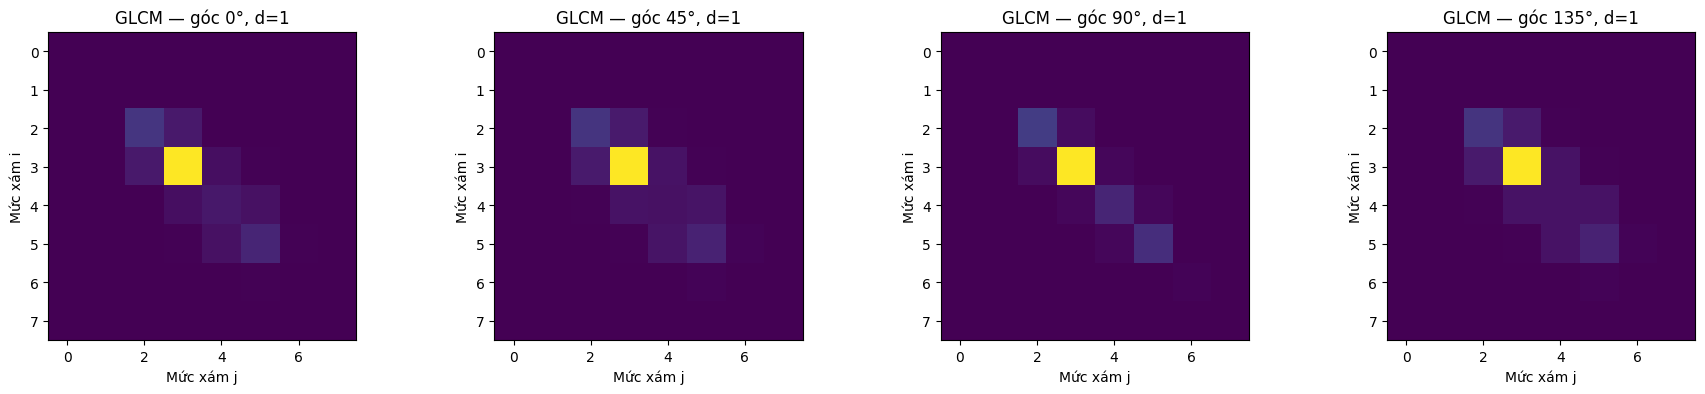

In [16]:
# Thử tính GLCM ở 4 hướng, d = 1
angles = [0, 45, 90, 135]
glcms_manual = {a: compute_glcm_manual(img_q, distance=1, angle_deg=a,
n_levels=N_LEVELS) for a in angles}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, a in zip(axes, angles):
  im = ax.imshow(glcms_manual[a], cmap='viridis')
  ax.set_title(f"GLCM — góc {a}°, d=1")
  ax.set_xlabel("Mức xám j"); ax.set_ylabel("Mức xám i")
plt.tight_layout()
plt.show()

Kích thước tensor GLCM (levels, levels, n_distance, n_angle): (8, 8, 1, 4)


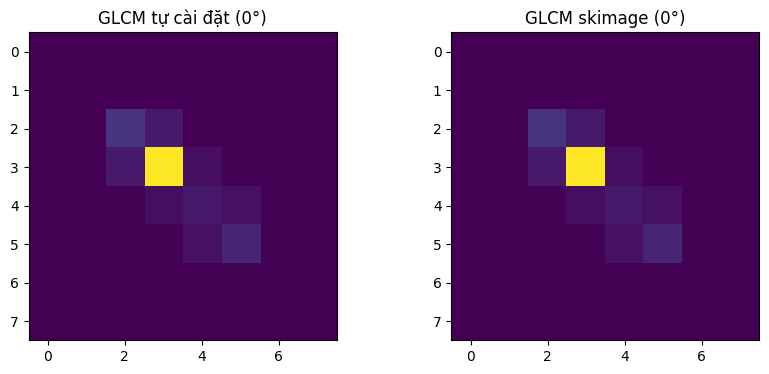

Sai lệch tối đa giữa 2 cách tính (nên gần 0): 0.000000


In [18]:
# BƯỚC 4.1 — Tính GLCM bằng skimage
distances = [1]                                   # d = 1 (giống bài báo gốc, Section III)
angles_rad = [0, np.pi/4, np.pi/2, 3*np.pi/4]      # 0°, 45°, 90°, 135° (đổi sang radian)

glcm_skimage = graycomatrix(
    img_q,
    distances=distances,
    angles=angles_rad,
    levels=N_LEVELS,
    symmetric=True,
    normed=True
)

print("Kích thước tensor GLCM (levels, levels, n_distance, n_angle):",
glcm_skimage.shape)

# So sánh trực quan GLCM tự cài đặt (Bước 3) với GLCM của skimage, ở góc 0°
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].imshow(glcms_manual[0], cmap='viridis'); ax[0].set_title("GLCM tự cài đặt (0°)")
ax[1].imshow(glcm_skimage[:,:,0,0], cmap='viridis'); ax[1].set_title("GLCM skimage (0°)")
plt.show()

diff = np.abs(glcms_manual[0] - glcm_skimage[:,:,0,0]).max()
print(f"Sai lệch tối đa giữa 2 cách tính (nên gần 0): {diff:.6f}")

In [19]:
# BƯỚC 5.1 — Cài đặt thủ công 3 đặc trưng minh họa f1, f2, f3 (đúng công thức (2)(4) trang 613)
def haralick_f1_asm(p):
    return np.sum(p ** 2)

def haralick_f2_contrast(p):
    Ng = p.shape[0]
    total = 0.0
    for n in range(Ng):
        idx_i, idx_j = np.indices(p.shape)
        mask = (np.abs(idx_i - idx_j) == n)
        total += (n ** 2) * p[mask].sum()
    return total

def haralick_f3_correlation(p):
    Ng = p.shape[0]
    i_idx, j_idx = np.indices(p.shape)
    px = p.sum(axis=1)   # marginal theo hàng
    py = p.sum(axis=0)   # marginal theo cột
    levels = np.arange(Ng)
    mu_x = np.sum(levels * px)
    mu_y = np.sum(levels * py)
    sigma_x = np.sqrt(np.sum(((levels - mu_x) ** 2) * px))
    sigma_y = np.sqrt(np.sum(((levels - mu_y) ** 2) * py))
    num = np.sum(i_idx * j_idx * p) - mu_x * mu_y
    denom = sigma_x * sigma_y
    return num / denom if denom != 0 else 0.0

print(f"{'Góc':>6} | {'f1 (ASM)':>10} | {'f2 (Contrast)':>14} | {'f3 (Correlation)':>17}")
print("-" * 55)
for a in angles:
  p = glcms_manual[a]
  f1 = haralick_f1_asm(p)
  f2 = haralick_f2_contrast(p)
  f3 = haralick_f3_correlation(p)
  print(f"{a:>5}° | {f1:>10.4f} | {f2:>14.4f} | {f3:>17.4f}")

   Góc |   f1 (ASM) |  f2 (Contrast) |  f3 (Correlation)
-------------------------------------------------------
    0° |     0.3860 |         0.2347 |            0.8178
   45° |     0.3739 |         0.2735 |            0.7876
   90° |     0.4355 |         0.0933 |            0.9276
  135° |     0.3745 |         0.2655 |            0.7939


In [20]:
# BƯỚC 5.2 — Trích xuất đặc trưng nhanh bằng skimage.feature.graycoprops
props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
print(f"{'Đặc trưng':<15}", "".join([f"{'':>10}{d}°" for d in [0,45,90,135]]))
feature_table = {}
for prop in props:
  values = graycoprops(glcm_skimage, prop)[0]   # shape: (n_angle,) vì n_distance=1
  feature_table[prop] = values
  row = "".join([f"{v:>12.4f}" for v in values])
  print(f"{prop:<15}{row}")

Đặc trưng                 0°          45°          90°          135°
contrast             0.2347      0.2655      0.0933      0.2735
dissimilarity        0.2115      0.2402      0.0917      0.2447
homogeneity          0.8966      0.8824      0.9543      0.8805
energy               0.6213      0.6120      0.6599      0.6115
correlation          0.8178      0.7939      0.9276      0.7876
ASM                  0.3860      0.3745      0.4355      0.3739


In [21]:
# BƯỚC 6.1 — Tính mean và range cho từng đặc trưng, qua 4 hướng
print(f"{'Đặc trưng':<15}{'Mean':>12}{'Range':>12}")
summary = {}
for prop, values in feature_table.items():
    mean_v = values.mean()
    range_v = values.max() - values.min()
    summary[prop] = (mean_v, range_v)
    print(f"{prop:<15}{mean_v:>12.4f}{range_v:>12.4f}")

Đặc trưng              Mean       Range
contrast             0.2167      0.1803
dissimilarity        0.1970      0.1531
homogeneity          0.9035      0.0738
energy               0.6262      0.0484
correlation          0.8317      0.1400
ASM                  0.3925      0.0616


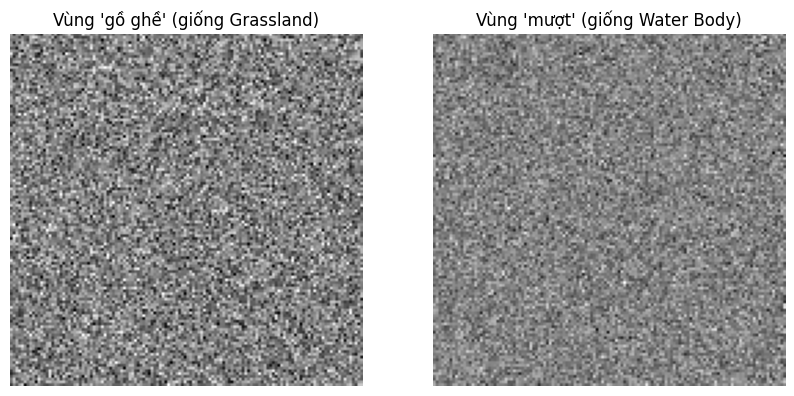

Đặc trưng         Rough (mean)   Smooth (mean)
ASM                     0.0381          0.2501
contrast                4.0954          0.4996
correlation            -0.0006          0.0006
homogeneity             0.4344          0.7502


In [22]:
# BƯỚC 7.1 — Tạo 2 ảnh minh họa: một ảnh "gồ ghề" (rough) và một ảnh "mượt" (smooth)
rng = np.random.default_rng(42)

# Ảnh "mượt" — biến thiên nhỏ, giống water body trong bài báo
smooth_img = (128 + rng.normal(0, 5, (128,128))).clip(0,255).astype(np.uint8)

# Ảnh "gồ ghề" — biến thiên lớn + cấu trúc chấm, giống grassland
rough_img = (128 + rng.normal(0, 45, (128,128))).clip(0,255).astype(np.uint8)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(rough_img, cmap='gray'); ax[0].set_title("Vùng 'gồ ghề' (giống Grassland)"); ax[0].axis('off')
ax[1].imshow(smooth_img, cmap='gray'); ax[1].set_title("Vùng 'mượt' (giống Water Body)"); ax[1].axis('off')
plt.show()

def extract_haralick_summary(img, n_levels=8, distance=1):
    img_q_local = quantize_image(img, n_levels)
    glcm = graycomatrix(img_q_local, distances=[distance], angles=angles_rad,
                         levels=n_levels, symmetric=True, normed=True)
    result = {}
    for prop in ['ASM', 'contrast', 'correlation', 'homogeneity']:
      vals = graycoprops(glcm, prop)[0]
      result[prop] = (vals.mean(), vals.max()-vals.min())
    return result

res_rough = extract_haralick_summary(rough_img)
res_smooth = extract_haralick_summary(smooth_img)
print(f"{'Đặc trưng':<15}{'Rough (mean)':>15}{'Smooth (mean)':>16}")
for prop in res_rough:
  print(f"{prop:<15}{res_rough[prop][0]:>15.4f}{res_smooth[prop][0]:>16.4f}")

In [24]:
# BƯỚC 8.1 — Sinh dữ liệu tổng hợp: N patch cho mỗi lớp "rough" và "smooth"
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

def make_patch(kind, size=64, seed=0):
    rng_local = np.random.default_rng(seed)
    if kind == 'rough':
        img = (128 + rng_local.normal(0, 45, (size, size))).clip(0,255).astype(np.uint8)
    else:
        img = (128 + rng_local.normal(0, 5, (size, size))).clip(0,255).astype(np.uint8)
    return img

def featurize(img, n_levels=8):
    s = extract_haralick_summary(img, n_levels=n_levels)
    # dùng giá trị mean của mỗi đặc trưng làm vector đặc trưng
    return [s['ASM'][0], s['contrast'][0], s['correlation'][0], s['homogeneity'][0]]

N_SAMPLES_PER_CLASS = 40
X, y = [], []
for k in range(N_SAMPLES_PER_CLASS):
    X.append(featurize(make_patch('rough', seed=k)));           y.append('rough')
    X.append(featurize(make_patch('smooth', seed=1000+k)));     y.append('smooth')

X = np.array(X)
y = np.array(y)
print("Kích thước tập dữ liệu:", X.shape)

# BƯỚC 8.2 — Chia train/test, huấn luyện SVM, đánh giá (tương tự tinh thần "min max decision rule" của bài báo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1,
stratify=y)

clf = SVC(kernel='linear')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred,
labels=['rough','smooth']))

Kích thước tập dữ liệu: (80, 4)
              precision    recall  f1-score   support

       rough       1.00      1.00      1.00        12
      smooth       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

Confusion matrix:
 [[12  0]
 [ 0 12]]


### BƯỚC 8.3 — Sử dụng ảnh thật (Real Images)
Bạn hãy tải 2 ảnh lên thư mục `/content/` với tên `data_rough.jpg` và `data_smooth.jpg` trước khi chạy cell dưới đây.

In [26]:
import os
from PIL import Image

def process_real_image(filepath, kind, patch_size=64):
    if not os.path.exists(filepath):
        print(f"Cảnh báo: Không tìm thấy file {filepath}")
        return [], []

    # Mở ảnh và chuyển về grayscale
    img = Image.open(filepath).convert('L')
    img_np = np.array(img)

    h, w = img_np.shape
    patches = []
    labels = []

    # Cắt ảnh thành các khối patch_size x patch_size
    for i in range(0, h - patch_size, patch_size):
        for j in range(0, w - patch_size, patch_size):
            patch = img_np[i:i+patch_size, j:j+patch_size]
            patches.append(featurize(patch))
            labels.append(kind)

    return patches, labels

# Khởi tạo tập dữ liệu mới từ ảnh thật
X_real, y_real = [], []

# Giả sử bạn đã upload 2 file này
p1, l1 = process_real_image('/content/tải xuống (4).webp', 'rough')
p2, l2 = process_real_image('/content/tải xuống (3).webp', 'smooth')

X_real.extend(p1); y_real.extend(l1)
X_real.extend(p2); y_real.extend(l2)

if len(X_real) > 0:
    X_real = np.array(X_real)
    y_real = np.array(y_real)

    # Chia tập dữ liệu và huấn luyện lại SVM
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_real, y_real, test_size=0.3, random_state=42)

    clf_real = SVC(kernel='linear')
    clf_real.fit(X_train_r, y_train_r)
    y_pred_r = clf_real.predict(X_test_r)

    print("KẾT QUẢ VỚI ẢNH THẬT:")
    print(classification_report(y_test_r, y_pred_r))
else:
    print("Hãy upload ảnh lên để thực hiện bước này!")

KẾT QUẢ VỚI ẢNH THẬT:
              precision    recall  f1-score   support

       rough       1.00      0.60      0.75         5
      smooth       0.33      1.00      0.50         1

    accuracy                           0.67         6
   macro avg       0.67      0.80      0.62         6
weighted avg       0.89      0.67      0.71         6

